Import the libraries

In [226]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

%matplotlib inline

Read the training data

In [1487]:
sp_titanic = pd.read_csv('train.csv')

In [1439]:
sp_titanic.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [910]:
sp_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [1188]:
sp_titanic.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


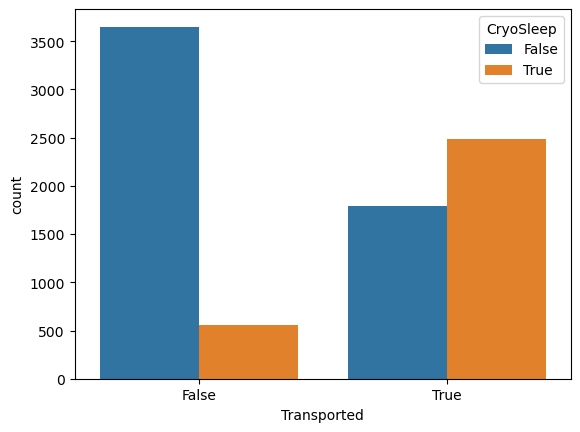

In [1048]:
sns.countplot(sp_titanic, x = 'Transported', hue = 'CryoSleep')
plt.show()

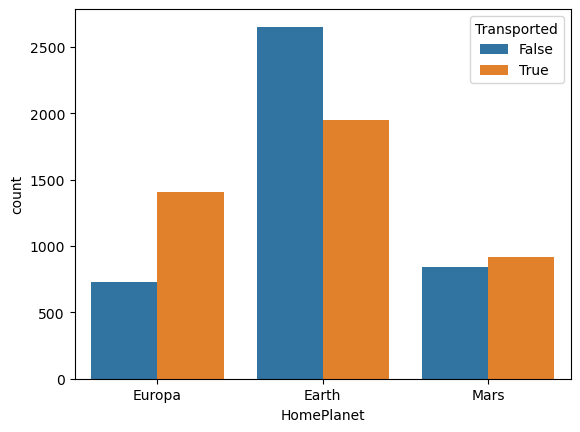

In [1049]:
sns.countplot(sp_titanic, x = 'HomePlanet', hue = 'Transported')
plt.show()

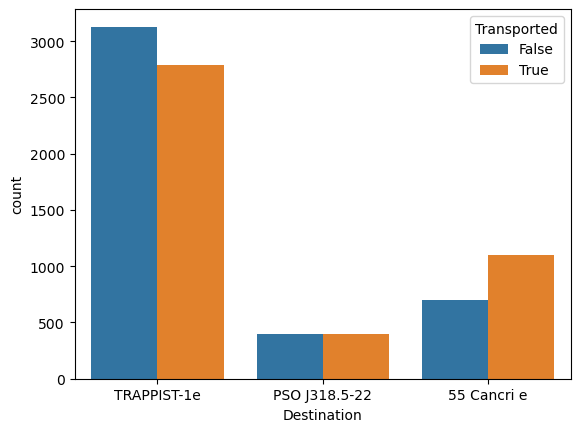

In [1050]:
sns.countplot(sp_titanic, x = 'Destination', hue = 'Transported')
plt.show()

In [1488]:
sp_titanic['GroupNum'] = sp_titanic['PassengerId'].apply(lambda passengerId : int(passengerId.split('_')[0]))
sp_titanic.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,GroupNum
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,1
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,2
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,3
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,3
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,4


In [1052]:
sp_titanic.groupby('GroupNum')['HomePlanet'].unique().apply(lambda p : len(p)).loc[lambda p : p > 1].sort_values(ascending = False)

GroupNum
64      2
119     2
444     2
445     2
470     2
       ..
8938    2
8961    2
9030    2
9072    2
9194    2
Name: HomePlanet, Length: 89, dtype: int64

In [1053]:
sp_titanic.groupby('GroupNum')['Destination'].unique().apply(lambda d : len(d)).loc[lambda d : d > 1].sort_values(ascending = False)

GroupNum
6405    4
8956    4
4001    4
714     4
9074    3
       ..
9118    2
9094    2
8988    2
8989    2
99      2
Name: Destination, Length: 771, dtype: int64

In [1489]:
def extractDeckNumSide(cabin):
    cabin_split = [None, None, None]
    if(type(cabin) == str):
      cabin_split = cabin.split('/')
    return cabin_split
sp_titanic[['Deck', 'Num', 'Side']] = pd.DataFrame(sp_titanic['Cabin'].apply(lambda cabin: extractDeckNumSide(cabin)).tolist())
sp_titanic.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,GroupNum,Deck,Num,Side
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,1,B,0,P
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,2,F,0,S
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,3,A,0,S
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,3,A,0,S
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,4,F,1,S


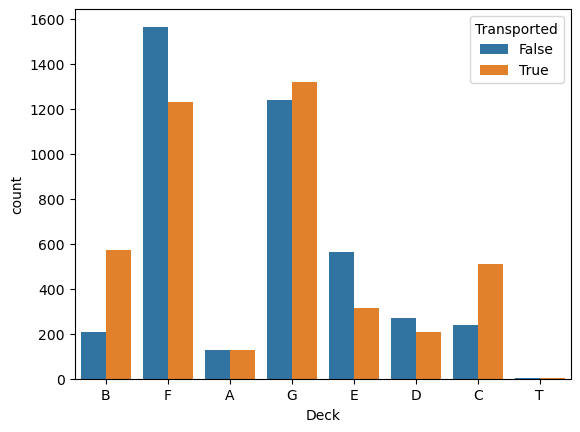

In [1055]:
sns.countplot(sp_titanic, hue = 'Transported', x = 'Deck')
plt.show()

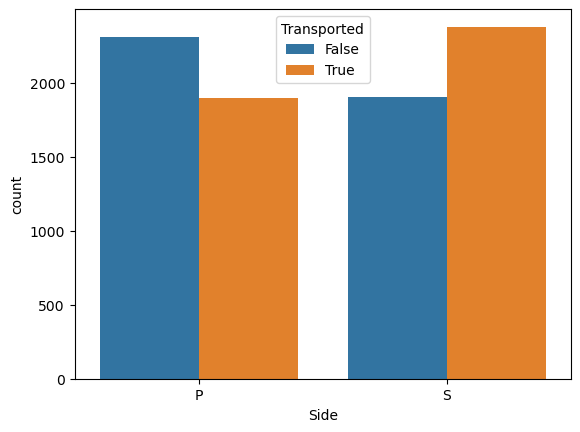

In [1056]:
sns.countplot(sp_titanic_original, hue = 'Transported', x = 'Side')
plt.show()

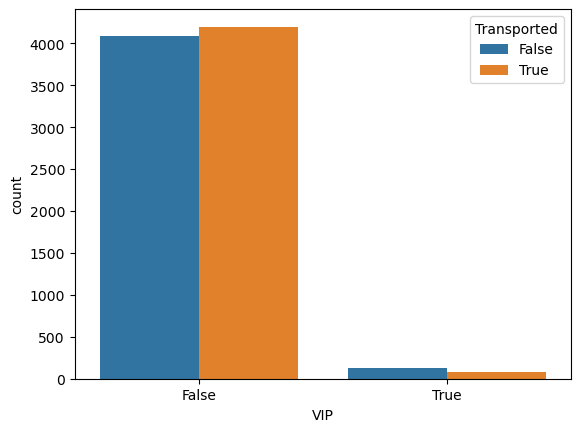

In [1057]:
sns.countplot(sp_titanic_original, hue = 'Transported', x = 'VIP')
plt.show()

In [1058]:
sp_titanic.groupby('GroupNum')['Deck'].unique().apply(lambda d : len(d)).loc[lambda d : d > 1].sort_values(ascending = False)

GroupNum
1709    4
2092    4
8129    4
938     3
1688    3
       ..
444     2
445     2
448     2
453     2
17      2
Name: Deck, Length: 508, dtype: int64

In [1490]:
def count_missing_val_per_column(dataframe):
    missing_val_per_col_dict = {}
    for col in dataframe.columns:
        missing_val_per_col_dict[col] = len(dataframe[dataframe[col].isnull()])
    return missing_val_per_col_dict
missing_val_per_col = pd.Series(count_missing_val_per_column(sp_titanic))
missing_val_per_col

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
GroupNum          0
Deck            199
Num             199
Side            199
dtype: int64

In [1060]:
len(sp_titanic.dropna())

6606

In [1491]:
sp_titanic_grouped_by_group_num = sp_titanic.groupby('GroupNum')['HomePlanet'].unique()
def populateHomePlanetField(homePlanet, groupNum):
  if(homePlanet != homePlanet):
      homePlanetsForGivenGroupNum = list(filter(lambda p : p==p,sp_titanic_grouped_by_group_num[groupNum]))
      if(len(homePlanetsForGivenGroupNum)>0):
          return homePlanetsForGivenGroupNum[0]
      else:
          return homePlanet
  return homePlanet
sp_titanic['HomePlanet'] = sp_titanic.apply(lambda row : populateHomePlanetField(row.HomePlanet, row.GroupNum), axis = 1)
pd.Series(count_missing_val_per_column(sp_titanic))

PassengerId       0
HomePlanet      111
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
GroupNum          0
Deck            199
Num             199
Side            199
dtype: int64

In [1343]:
from sklearn.model_selection import train_test_split

In [1493]:
X_train, X_test, y_train, y_test = train_test_split(sp_titanic.drop(['Transported', 'Cabin', 'Name', 'PassengerId'], axis = 1).astype(str), sp_titanic['Transported'], test_size = 0.3)

In [1345]:
from catboost import CatBoostClassifier

In [1494]:
catboost_model = CatBoostClassifier(iterations=600, learning_rate=0.03, depth=6, verbose=0)

In [1350]:
sp_titanic['CryoSleep'].unique()

array([False, True, nan], dtype=object)

In [1495]:
catboost_model.fit(X_train, y_train, cat_features = ['HomePlanet', 'Destination', 'CryoSleep', 'Deck', 'Side', 'VIP'])

In [1496]:
predictions_catboost = catboost_model.predict(X_test)

In [1355]:
from sklearn.metrics import classification_report, confusion_matrix

In [1497]:
print(confusion_matrix(y_test, predictions_catboost))

[[1048  241]
 [ 267 1052]]


In [1498]:
print(classification_report(y_test, predictions_catboost))

              precision    recall  f1-score   support

       False       0.80      0.81      0.80      1289
        True       0.81      0.80      0.81      1319

    accuracy                           0.81      2608
   macro avg       0.81      0.81      0.81      2608
weighted avg       0.81      0.81      0.81      2608



In [1499]:
sp_titanic[['CryoSleep_False', 'CryoSleep_True']] = pd.get_dummies(sp_titanic['CryoSleep'])
sp_titanic[(sp_titanic['CryoSleep_False'] == False) & (sp_titanic['CryoSleep_True'] == False)]

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,GroupNum,Deck,Num,Side,CryoSleep_False,CryoSleep_True
92,0099_02,Earth,NaN,G/12/P,TRAPPIST-1e,2.0,False,0.0,0.0,0.0,0.0,0.0,Thewis Connelson,True,99,G,12,P,False,False
98,0105_01,Earth,NaN,F/21/P,TRAPPIST-1e,27.0,False,0.0,0.0,570.0,2.0,131.0,Carry Cleachrand,False,105,F,21,P,False,False
104,0110_02,Europa,NaN,B/5/P,TRAPPIST-1e,40.0,False,0.0,331.0,0.0,0.0,1687.0,Aldeba Bootious,False,110,B,5,P,False,False
111,0115_01,Mars,NaN,F/24/P,TRAPPIST-1e,26.0,False,0.0,0.0,0.0,0.0,NaN,Rohs Pead,True,115,F,24,P,False,False
152,0173_01,Earth,NaN,E/11/S,TRAPPIST-1e,58.0,False,0.0,985.0,0.0,5.0,0.0,Hilip Grifford,True,173,E,11,S,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8620,9197_01,Europa,NaN,C/308/P,55 Cancri e,44.0,False,0.0,0.0,0.0,0.0,0.0,Bellus Platch,True,9197,C,308,P,False,False
8651,9227_05,Earth,NaN,G/1498/P,TRAPPIST-1e,8.0,False,0.0,0.0,0.0,0.0,0.0,Hard Hinglendez,False,9227,G,1498,P,False,False
8664,9246_01,Earth,NaN,G/1490/S,TRAPPIST-1e,32.0,False,0.0,0.0,0.0,0.0,0.0,NaN,True,9246,G,1490,S,False,False
8675,9259_01,Earth,NaN,F/1893/P,TRAPPIST-1e,44.0,False,1030.0,1015.0,0.0,11.0,NaN,Annah Gilleyons,True,9259,F,1893,P,False,False


In [1500]:
sp_titanic = pd.concat([sp_titanic, pd.get_dummies(sp_titanic['HomePlanet']), pd.get_dummies(sp_titanic['Destination'])], axis = 1)
sp_titanic[(sp_titanic['Earth'] == False) & (sp_titanic['Mars'] == False) & (sp_titanic['Europa'] == False)]

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,...,Num,Side,CryoSleep_False,CryoSleep_True,Earth,Europa,Mars,55 Cancri e,PSO J318.5-22,TRAPPIST-1e
186,0210_01,NaN,True,D/6/P,55 Cancri e,24.0,False,0.0,0.0,NaN,...,6,P,False,True,False,False,False,True,False,False
225,0242_01,NaN,False,F/46/S,TRAPPIST-1e,18.0,False,313.0,1.0,691.0,...,46,S,True,False,False,False,False,False,False,True
234,0251_01,NaN,True,C/11/S,55 Cancri e,54.0,False,0.0,0.0,0.0,...,11,S,False,True,False,False,False,True,False,False
274,0303_01,NaN,True,G/41/S,TRAPPIST-1e,23.0,False,0.0,0.0,0.0,...,41,S,False,True,False,False,False,False,False,True
286,0315_01,NaN,True,G/42/S,PSO J318.5-22,35.0,False,0.0,0.0,0.0,...,42,S,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8468,9043_01,NaN,True,F/1848/P,TRAPPIST-1e,25.0,False,0.0,0.0,0.0,...,1848,P,False,True,False,False,False,False,False,True
8515,9084_01,NaN,False,E/582/P,TRAPPIST-1e,25.0,False,1258.0,0.0,22.0,...,582,P,True,False,False,False,False,False,False,True
8666,9248_01,NaN,False,F/1792/S,55 Cancri e,38.0,NaN,28.0,1208.0,973.0,...,1792,S,True,False,False,False,False,True,False,False
8674,9257_01,NaN,False,F/1892/P,TRAPPIST-1e,13.0,False,39.0,0.0,1085.0,...,1892,P,True,False,False,False,False,False,False,True


In [1501]:
sp_titanic[(sp_titanic['55 Cancri e'] == False) & (sp_titanic['PSO J318.5-22'] == False) & (sp_titanic['TRAPPIST-1e'] == False)]

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,...,Num,Side,CryoSleep_False,CryoSleep_True,Earth,Europa,Mars,55 Cancri e,PSO J318.5-22,TRAPPIST-1e
47,0045_02,Mars,True,F/10/P,NaN,19.0,False,0.0,0.0,0.0,...,10,P,False,True,False,False,True,False,False,False
128,0138_02,Earth,False,E/5/P,NaN,34.0,False,0.0,22.0,0.0,...,5,P,True,False,True,False,False,False,False,False
139,0152_01,Earth,False,F/32/P,NaN,41.0,False,0.0,0.0,0.0,...,32,P,True,False,True,False,False,False,False,False
347,0382_01,NaN,False,G/64/P,NaN,23.0,False,348.0,0.0,0.0,...,64,P,True,False,False,False,False,False,False,False
430,0462_01,Earth,True,G/67/S,NaN,50.0,False,0.0,0.0,0.0,...,67,S,False,True,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8372,8956_02,Earth,True,G/1453/P,NaN,20.0,False,0.0,0.0,0.0,...,1453,P,False,True,True,False,False,False,False,False
8551,9130_01,Mars,True,F/1765/S,NaN,41.0,False,0.0,0.0,0.0,...,1765,S,False,True,False,False,True,False,False,False
8616,9195_02,Mars,True,F/1779/S,NaN,33.0,False,0.0,0.0,0.0,...,1779,S,False,True,False,False,True,False,False,False
8621,9197_02,Europa,False,C/308/P,NaN,41.0,True,0.0,7964.0,0.0,...,308,P,True,False,False,True,False,False,False,False


In [1502]:
sp_titanic[['VIP_False', 'VIP_True']] = pd.get_dummies(sp_titanic['VIP'])
sp_titanic[(sp_titanic['VIP_False'] == False) & (sp_titanic['VIP_True'] == False)]

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,...,CryoSleep_False,CryoSleep_True,Earth,Europa,Mars,55 Cancri e,PSO J318.5-22,TRAPPIST-1e,VIP_False,VIP_True
38,0036_01,Earth,False,F/8/S,55 Cancri e,15.0,NaN,0.0,492.0,48.0,...,True,False,True,False,False,True,False,False,False,False
102,0108_03,Earth,False,G/19/S,TRAPPIST-1e,0.0,NaN,0.0,0.0,0.0,...,True,False,True,False,False,False,False,True,False,False
145,0165_01,Mars,True,F/37/P,TRAPPIST-1e,35.0,NaN,0.0,0.0,0.0,...,False,True,False,False,True,False,False,True,False,False
228,0244_02,Mars,True,F/47/S,55 Cancri e,14.0,NaN,0.0,0.0,0.0,...,False,True,False,False,True,True,False,False,False,False
566,0593_01,Mars,False,D/24/P,TRAPPIST-1e,NaN,NaN,43.0,152.0,182.0,...,True,False,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8494,9074_01,Earth,True,G/1460/S,TRAPPIST-1e,0.0,NaN,0.0,0.0,NaN,...,False,True,True,False,False,False,False,True,False,False
8512,9081_06,Earth,False,F/1858/P,PSO J318.5-22,16.0,NaN,0.0,0.0,761.0,...,True,False,True,False,False,False,True,False,False,False
8542,9122_01,Earth,True,G/1469/S,55 Cancri e,55.0,NaN,0.0,0.0,0.0,...,False,True,True,False,False,True,False,False,False,False
8630,9205_03,Europa,True,B/300/P,TRAPPIST-1e,52.0,NaN,0.0,0.0,0.0,...,False,True,False,True,False,False,False,True,False,False


In [1503]:
def replaceNansWithZeros(num):
    if(num!=num):
        return 0
    else:
        return num
for col in ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']:
    sp_titanic[col] = sp_titanic[col].apply(lambda num : replaceNansWithZeros(num))
pd.Series(count_missing_val_per_column(sp_titanic))

PassengerId          0
HomePlanet         111
CryoSleep          217
Cabin              199
Destination        182
Age                179
VIP                203
RoomService          0
FoodCourt            0
ShoppingMall         0
Spa                  0
VRDeck               0
Name               200
Transported          0
GroupNum             0
Deck               199
Num                199
Side               199
CryoSleep_False      0
CryoSleep_True       0
Earth                0
Europa               0
Mars                 0
55 Cancri e          0
PSO J318.5-22        0
TRAPPIST-1e          0
VIP_False            0
VIP_True             0
dtype: int64

In [1504]:
sp_titanic['Age'] = sp_titanic['Age'].apply(lambda age : 0 if(age != age) else age)
sp_titanic[sp_titanic['Age'].isnull()]

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,...,CryoSleep_False,CryoSleep_True,Earth,Europa,Mars,55 Cancri e,PSO J318.5-22,TRAPPIST-1e,VIP_False,VIP_True


In [1505]:
deck_list = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T']
for i in range(len(deck_list)):
    deck_list[i] += '_Deck'
sp_titanic[deck_list] = pd.get_dummies(sp_titanic['Deck'])
sp_titanic[deck_list]

,A_Deck,B_Deck,C_Deck,D_Deck,E_Deck,F_Deck,G_Deck,T_Deck
0,False,True,False,False,False,False,False,False
1,False,False,False,False,False,True,False,False
2,True,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False
4,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...
8688,True,False,False,False,False,False,False,False
8689,False,False,False,False,False,False,True,False
8690,False,False,False,False,False,False,True,False
8691,False,False,False,False,True,False,False,False


In [1506]:
sp_titanic['Num'] = sp_titanic['Num'].apply(lambda num : 0 if(num == None) else int(num))
sp_titanic[sp_titanic['Num'].isnull()]['Num']

Series([], Name: Num, dtype: int64)

In [1507]:
sp_titanic[['P_Side', 'S_Side']] = pd.get_dummies(sp_titanic['Side'])
sp_titanic[['P_Side', 'S_Side']]

,P_Side,S_Side
0,True,False
1,False,True
2,False,True
3,False,True
4,False,True
...,...,...
8688,True,False
8689,False,True
8690,False,True
8691,False,True


In [1508]:
sp_titanic = sp_titanic.drop(['HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Name', 'VIP','Deck', 'Side', 'PassengerId'], axis = 1)
pd.Series(count_missing_val_per_column(sp_titanic))

Age                0
RoomService        0
FoodCourt          0
ShoppingMall       0
Spa                0
VRDeck             0
Transported        0
GroupNum           0
Num                0
CryoSleep_False    0
CryoSleep_True     0
Earth              0
Europa             0
Mars               0
55 Cancri e        0
PSO J318.5-22      0
TRAPPIST-1e        0
VIP_False          0
VIP_True           0
A_Deck             0
B_Deck             0
C_Deck             0
D_Deck             0
E_Deck             0
F_Deck             0
G_Deck             0
T_Deck             0
P_Side             0
S_Side             0
dtype: int64

In [1509]:
sp_titanic.corr()['Transported']

Age               -0.071330
RoomService       -0.241124
FoodCourt          0.045583
ShoppingMall       0.009391
Spa               -0.218545
VRDeck            -0.204874
Transported        1.000000
GroupNum           0.021491
Num               -0.043832
CryoSleep_False   -0.451744
CryoSleep_True     0.460132
Earth             -0.170534
Europa             0.179756
Mars               0.019941
55 Cancri e        0.108722
PSO J318.5-22      0.000092
TRAPPIST-1e       -0.094700
VIP_False          0.024602
VIP_True          -0.037261
A_Deck            -0.002623
B_Deck             0.144733
C_Deck             0.108193
D_Deck            -0.034046
E_Deck            -0.097965
F_Deck            -0.087753
G_Deck             0.016269
T_Deck            -0.014568
P_Side            -0.101397
S_Side             0.101455
Name: Transported, dtype: float64

In [1510]:
scaler = MinMaxScaler()

In [1511]:
scaler.fit(sp_titanic.drop('Transported', axis = 1))

MinMaxScaler()

In [1512]:
sp_titanic_scaled = scaler.transform(sp_titanic.drop('Transported', axis = 1))

In [1513]:
pd.DataFrame(sp_titanic_scaled, columns = sp_titanic.drop('Transported', axis = 1).columns).head()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,GroupNum,Num,CryoSleep_False,CryoSleep_True,...,A_Deck,B_Deck,C_Deck,D_Deck,E_Deck,F_Deck,G_Deck,T_Deck,P_Side,S_Side
0,0.493671,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.303797,0.007608,0.000302,0.001064,0.024500,0.001823,0.000108,0.000000,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,0.734177,0.003001,0.119948,0.000000,0.299670,0.002030,0.000216,0.000000,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.417722,0.000000,0.043035,0.015793,0.148563,0.007997,0.000216,0.000000,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.202532,0.021149,0.002348,0.006428,0.025214,0.000083,0.000323,0.000528,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [1514]:
X_train, X_test, y_train, y_test = train_test_split(sp_titanic_scaled, sp_titanic['Transported'], test_size = 0.3)

In [938]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation

In [1515]:
model = Sequential()
model.add(Dense(28, activation = 'relu'))
model.add(Dense(30, activation = 'relu'))
model.add(Dense(30, activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))

model.compile(optimizer='adam',loss='binary_crossentropy')

In [1516]:
model.fit(X_train, y_train, epochs = 150)

Epoch 1/150
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.6110 
Epoch 2/150
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5222  
Epoch 3/150
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4893  
Epoch 4/150
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4655  
Epoch 5/150
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4470  
Epoch 6/150
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4345  
Epoch 7/150
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4243 
Epoch 8/150
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4175  
Epoch 9/150
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4127  
Epoch 10/150
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4097  
Epoch 11/150
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4032  
Epoch 12/150
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4022  
Epoch 13/150
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3983  
Epoch 14/150
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3957  
Epoch 15/150
191/

In [1517]:
predictions = model.predict(X_test)

82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step   


In [1530]:
predictions_bool = np.array([x >= 0.5 for x in predictions]).reshape(2608,)

In [1531]:
print(confusion_matrix(np.array(y_test), predictions_bool))

[[ 977  296]
 [ 243 1092]]


In [1532]:
print(classification_report(np.array(y_test), predictions_bool))

              precision    recall  f1-score   support

       False       0.80      0.77      0.78      1273
        True       0.79      0.82      0.80      1335

    accuracy                           0.79      2608
   macro avg       0.79      0.79      0.79      2608
weighted avg       0.79      0.79      0.79      2608



In [1533]:
for col in sp_titanic.columns:
    if(sp_titanic[col].dtype == bool):
        sp_titanic[col] = sp_titanic[col].apply(lambda bool_val : 1 if(bool_val) else 0)
        
sp_titanic.head()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,GroupNum,Num,CryoSleep_False,...,A_Deck,B_Deck,C_Deck,D_Deck,E_Deck,F_Deck,G_Deck,T_Deck,P_Side,S_Side
0,39.0,0.0,0.0,0.0,0.0,0.0,0,1,0,1,...,0,1,0,0,0,0,0,0,1,0
1,24.0,109.0,9.0,25.0,549.0,44.0,1,2,0,1,...,0,0,0,0,0,1,0,0,0,1
2,58.0,43.0,3576.0,0.0,6715.0,49.0,0,3,0,1,...,1,0,0,0,0,0,0,0,0,1
3,33.0,0.0,1283.0,371.0,3329.0,193.0,0,3,0,1,...,1,0,0,0,0,0,0,0,0,1
4,16.0,303.0,70.0,151.0,565.0,2.0,1,4,1,1,...,0,0,0,0,0,1,0,0,0,1


In [341]:
from sklearn.linear_model import LogisticRegression

In [1534]:
X_train, X_test, y_train, y_test = train_test_split(sp_titanic.drop('Transported', axis = 1), sp_titanic['Transported'], test_size = 0.3)

In [1535]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [1536]:
predictions_log_reg = log_model.predict(X_test)

In [1537]:
print(confusion_matrix(y_test, predictions_log_reg))

[[ 993  299]
 [ 271 1045]]


In [1538]:
print(classification_report(y_test, predictions_log_reg))

              precision    recall  f1-score   support

           0       0.79      0.77      0.78      1292
           1       0.78      0.79      0.79      1316

    accuracy                           0.78      2608
   macro avg       0.78      0.78      0.78      2608
weighted avg       0.78      0.78      0.78      2608



In [955]:
from sklearn.tree import DecisionTreeClassifier

In [1539]:
tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)

DecisionTreeClassifier()

In [1541]:
predictions_tree = tree_model.predict(X_test)

In [1542]:
print(confusion_matrix(y_test, predictions_tree))

[[955 337]
 [319 997]]


In [1543]:
print(classification_report(y_test, predictions_tree))

              precision    recall  f1-score   support

           0       0.75      0.74      0.74      1292
           1       0.75      0.76      0.75      1316

    accuracy                           0.75      2608
   macro avg       0.75      0.75      0.75      2608
weighted avg       0.75      0.75      0.75      2608



In [960]:
from sklearn.ensemble import RandomForestClassifier

In [1544]:
rfc = RandomForestClassifier(n_estimators = 400)
rfc.fit(X_train, y_train)

RandomForestClassifier(n_estimators=400)

In [1545]:
predictions_rfc = rfc.predict(X_test)

In [1546]:
print(confusion_matrix(y_test, predictions_rfc))

[[1088  204]
 [ 317  999]]


In [1547]:
print(classification_report(y_test, predictions_rfc))

              precision    recall  f1-score   support

           0       0.77      0.84      0.81      1292
           1       0.83      0.76      0.79      1316

    accuracy                           0.80      2608
   macro avg       0.80      0.80      0.80      2608
weighted avg       0.80      0.80      0.80      2608



In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

In [1172]:
param_grid = {'C' : [1.45, 1.5, 1.55], 'gamma' : [0.00000044, 0.00000045, 0.00000046], 'kernel' : ['rbf']}
grid = GridSearchCV(SVC(), param_grid, refit = True, verbose = 3)
grid.fit(X_train, y_train)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV 1/5] END .C=1.45, gamma=4.4e-07, kernel=rbf;, score=0.781 total time=   2.3s
[CV 2/5] END .C=1.45, gamma=4.4e-07, kernel=rbf;, score=0.781 total time=   2.7s
[CV 3/5] END .C=1.45, gamma=4.4e-07, kernel=rbf;, score=0.781 total time=   2.6s
[CV 4/5] END .C=1.45, gamma=4.4e-07, kernel=rbf;, score=0.779 total time=   3.3s
[CV 5/5] END .C=1.45, gamma=4.4e-07, kernel=rbf;, score=0.763 total time=   3.4s
[CV 1/5] END .C=1.45, gamma=4.5e-07, kernel=rbf;, score=0.781 total time=   2.0s
[CV 2/5] END .C=1.45, gamma=4.5e-07, kernel=rbf;, score=0.781 total time=   1.7s
[CV 3/5] END .C=1.45, gamma=4.5e-07, kernel=rbf;, score=0.781 total time=   1.8s
[CV 4/5] END .C=1.45, gamma=4.5e-07, kernel=rbf;, score=0.779 total time=   1.8s
[CV 5/5] END .C=1.45, gamma=4.5e-07, kernel=rbf;, score=0.763 total time=   2.3s
[CV 1/5] END .C=1.45, gamma=4.6e-07, kernel=rbf;, score=0.780 total time=   2.7s
[CV 2/5] END .C=1.45, gamma=4.6e-07, kernel=rbf;,

GridSearchCV(estimator=SVC(),
             param_grid={'C': [1.45, 1.5, 1.55],
                         'gamma': [4.4e-07, 4.5e-07, 4.6e-07],
                         'kernel': ['rbf']},
             verbose=3)

In [1116]:
grid.best_params_

{'C': 1.45, 'gamma': 4.5e-07, 'kernel': 'rbf'}

In [1117]:
grid.best_estimator_

SVC(C=1.45, gamma=4.5e-07)

In [1118]:
predictions_grid = grid.predict(X_test)

In [1119]:
print(confusion_matrix(y_test, predictions_grid))

[[1020  269]
 [ 436  883]]


In [1120]:
print(classification_report(y_test, predictions_grid))

              precision    recall  f1-score   support

           0       0.70      0.79      0.74      1289
           1       0.77      0.67      0.71      1319

    accuracy                           0.73      2608
   macro avg       0.73      0.73      0.73      2608
weighted avg       0.73      0.73      0.73      2608



In [1175]:
import xgboost as xgb

In [1548]:
xgb_model = xgb.XGBClassifier(n_estimators = 500, max_depth=100)

In [1549]:
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=100,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [1550]:
predictions_xgb = xgb_model.predict(X_test)

In [1551]:
print(confusion_matrix(y_test, predictions_xgb))

[[1056  236]
 [ 300 1016]]


In [1552]:
print(classification_report(y_test, predictions_xgb))

              precision    recall  f1-score   support

           0       0.78      0.82      0.80      1292
           1       0.81      0.77      0.79      1316

    accuracy                           0.79      2608
   macro avg       0.80      0.79      0.79      2608
weighted avg       0.80      0.79      0.79      2608



In [1553]:
catboost_model = CatBoostClassifier(iterations=200, learning_rate=0.1, depth=6, verbose=0)

In [1554]:
catboost_model.fit(X_train, y_train)

In [1555]:
predictions_catboost = catboost_model.predict(X_test)

In [1556]:
print(confusion_matrix(y_test, predictions_catboost))

[[1033  259]
 [ 246 1070]]


In [1557]:
print(classification_report(y_test, predictions_catboost))

              precision    recall  f1-score   support

           0       0.81      0.80      0.80      1292
           1       0.81      0.81      0.81      1316

    accuracy                           0.81      2608
   macro avg       0.81      0.81      0.81      2608
weighted avg       0.81      0.81      0.81      2608



In [1558]:
sp_titanic_test = pd.read_csv('test.csv')

In [1559]:
sp_titanic_test.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


In [1560]:
sp_titanic_test[['Deck', 'Num', 'Side']] = pd.DataFrame(sp_titanic_test['Cabin'].apply(lambda cabin: extractDeckNumSide(cabin)).tolist())
sp_titanic_test.head()
sp_titanic_test[['CryoSleep_False', 'CryoSleep_True']] = pd.get_dummies(sp_titanic_test['CryoSleep'])
sp_titanic_test['GroupNum'] = sp_titanic_test['PassengerId'].apply(lambda passengerId : int(passengerId.split('_')[0]))
sp_titanic_test_grouped_by_group_num = sp_titanic_test.groupby('GroupNum')['HomePlanet'].unique()
def populateHomePlanetFieldTestData(homePlanet, groupNum):
  if(homePlanet != homePlanet):
      homePlanetsForGivenGroupNum = list(filter(lambda p : p==p,sp_titanic_test_grouped_by_group_num[groupNum]))
      if(len(homePlanetsForGivenGroupNum)>0):
          return homePlanetsForGivenGroupNum[0]
      else:
          return homePlanet
  return homePlanet
sp_titanic_test['HomePlanet'] = sp_titanic_test.apply(lambda row : populateHomePlanetFieldTestData(row.HomePlanet, row.GroupNum), axis = 1)
sp_titanic_test = pd.concat([sp_titanic_test, pd.get_dummies(sp_titanic_test['HomePlanet']), pd.get_dummies(sp_titanic_test['Destination'])], axis = 1)
sp_titanic_test[['VIP_False', 'VIP_True']] = pd.get_dummies(sp_titanic_test['VIP'])
for col in ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']:
    sp_titanic_test[col] = sp_titanic_test[col].apply(lambda num : replaceNansWithZeros(num))
sp_titanic_test['Age'] = sp_titanic_test['Age'].apply(lambda age : 0 if(age != age) else age)
sp_titanic_test[deck_list] = pd.get_dummies(sp_titanic_test['Deck'])
sp_titanic_test['Num'] = sp_titanic_test['Num'].apply(lambda num : 0 if(num == None) else int(num))
sp_titanic_test[['P_Side', 'S_Side']] = pd.get_dummies(sp_titanic_test['Side'])
sp_titanic_test = sp_titanic_test.drop(['HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Name', 'VIP','Deck', 'Side'], axis = 1)
sp_titanic_test.head()

,PassengerId,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Num,CryoSleep_False,CryoSleep_True,...,A_Deck,B_Deck,C_Deck,D_Deck,E_Deck,F_Deck,G_Deck,T_Deck,P_Side,S_Side
0,0013_01,27.0,0.0,0.0,0.0,0.0,0.0,3,False,True,...,False,False,False,False,False,False,True,False,False,True
1,0018_01,19.0,0.0,9.0,0.0,2823.0,0.0,4,True,False,...,False,False,False,False,False,True,False,False,False,True
2,0019_01,31.0,0.0,0.0,0.0,0.0,0.0,0,False,True,...,False,False,True,False,False,False,False,False,False,True
3,0021_01,38.0,0.0,6652.0,0.0,181.0,585.0,1,True,False,...,False,False,True,False,False,False,False,False,False,True
4,0023_01,20.0,10.0,0.0,635.0,0.0,0.0,5,True,False,...,False,False,False,False,False,True,False,False,False,True


In [1561]:
test_predictions = catboost_model.predict(sp_titanic_test.drop('PassengerId', axis = 1))

In [1562]:
results = pd.DataFrame({'PassengerId' : sp_titanic_test['PassengerId'].tolist(), 'Transported' : test_predictions})
results.set_index('PassengerId', inplace = True)
results['Transported'] = results['Transported'].apply(lambda t : bool(t))
results.head()

,Transported
PassengerId,
0013_01,True
0018_01,False
0019_01,True
0021_01,True
0023_01,True


In [1563]:
results.to_csv('submission.csv')